# 04 · End-to-end evaluation and the LLMOps gate

> **Goal.** Run the whole pipeline — ingest → retrieve → generate → evaluate —
> over the golden set, persist traces, and enforce a **regression gate** with
> the same pass/fail logic a CI job would use. This is the evaluation-first
> thesis made executable.

A RAG system is only trustworthy if quality is a *gate*, not a vibe. Here we
score every golden question across retrieval and answer metrics, visualise the
distributions and operational budgets, persist a `RagTrace` per request, and
fail the build when faithfulness or citation support falls below threshold.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ragops_lab.ingestion import ChunkingConfig, ingest_directory, load_chunks_jsonl
from ragops_lab.retrieval import (
    BM25Retriever,
    FakeEmbeddingClient,
    HybridRetriever,
    RetrievalGoldenExample,
    VectorRetriever,
    evaluate_retrieval,
    tokenize,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 88)

DATA = Path("../data")
ARTIFACTS = Path("../artifacts")
CHUNKING = ChunkingConfig(chunk_size=400, overlap=60)


def build_corpus() -> list:
    """Ingest the sample corpus into chunks (the shared starting point)."""
    return ingest_directory(DATA / "sample_documents", DATA / "processed" / "chunks.jsonl", CHUNKING)


def shared_vocabulary(chunks: list) -> list[str]:
    """Fixed vocabulary so query and chunk embeddings share a vector space."""
    return sorted({term for chunk in chunks for term in tokenize(chunk.text)})


def load_golden() -> list[RetrievalGoldenExample]:
    """Load the golden retrieval set."""
    rows = json.loads((DATA / "golden" / "qa.json").read_text())
    return [RetrievalGoldenExample(**row) for row in rows]

In [2]:
from ragops_lab.evaluation import (
    evaluate_answer,
    export_evaluation_report_csv,
    export_evaluation_report_markdown,
)
from ragops_lab.generation import GenerationService, HeuristicLLMClient
from ragops_lab.tracing import JsonlTraceStore
from ragops_lab.domain import RagTrace

chunks = build_corpus()
golden_raw = json.loads((DATA / "golden" / "qa.json").read_text())
retriever = BM25Retriever(chunks)
service = GenerationService(HeuristicLLMClient())
EVAL_DIR = ARTIFACTS / "evaluation"

## 1. Score every golden question and persist a trace

For each question we retrieve, generate, evaluate, and store a `RagTrace`
carrying the retrieved chunks, the answer, the evaluation, latency, and a token
estimate — the record an operator would later inspect to explain any answer.

In [3]:
trace_store = JsonlTraceStore(ARTIFACTS / "traces" / "eval_run.jsonl")
if trace_store.path.exists():
    trace_store.path.unlink()

records = []
results_by_q = {}
for index, example in enumerate(golden_raw):
    question = example["query"]
    reference_ids = example["relevant_chunk_ids"]

    start = time.perf_counter()
    contexts = retriever.search(question, top_k=3)
    answer = service.answer(question, contexts, model_name="heuristic-local")
    latency_ms = (time.perf_counter() - start) * 1000

    evaluation = evaluate_answer(question, answer, contexts, reference_chunk_ids=reference_ids)
    token_estimate = len(tokenize(answer.prompt or "")) + len(tokenize(answer.answer_text))
    results_by_q[question] = (answer, contexts, evaluation)

    trace_store.save(
        RagTrace(
            trace_id=f"eval-{index:02d}",
            question=question,
            retrieved_chunks=contexts,
            answer=answer,
            evaluation=evaluation,
            model_name="heuristic-local",
            latency_ms=latency_ms,
            token_estimate=token_estimate,
        )
    )
    records.append(
        {
            "question": question[:40],
            "ctx_precision": evaluation.context_precision,
            "ctx_recall": evaluation.context_recall,
            "relevance": evaluation.answer_relevance,
            "faithfulness": evaluation.faithfulness,
            "citation": evaluation.citation_support,
            "unsupported": evaluation.unsupported_claim_count,
            "latency_ms": latency_ms,
            "tokens": token_estimate,
        }
    )

frame = pd.DataFrame(records)
print(f"evaluated {len(frame)} questions · persisted {len(trace_store.list())} traces")
frame.round(3).head(8)

evaluated 16 questions · persisted 16 traces


,question,ctx_precision,ctx_recall,relevance,faithfulness,citation,unsupported,latency_ms,tokens
0,What does the BM25 k1 parameter control?,0.333,1.0,0.143,1.0,1.0,0,0.518,234
1,What are common default values for BM25,0.667,1.0,0.200,1.0,1.0,0,0.480,237
2,What is the main weakness of lexical ret,0.333,1.0,0.000,1.0,1.0,0,0.447,227
3,Which similarity metric is standard for,0.333,1.0,0.375,1.0,1.0,0,0.458,226
4,Why do vector systems use approximate ne,0.333,1.0,0.667,1.0,1.0,0,0.420,237
5,How does the alpha weight blend scores i,0.333,1.0,0.000,1.0,1.0,0,0.476,231
6,What is Reciprocal Rank Fusion?,0.333,1.0,0.000,1.0,1.0,0,0.410,227
7,What is the trade-off between small and,0.333,1.0,0.000,1.0,1.0,0,0.619,236


## 2. Metric distributions across the dataset

Two metrics need honest framing before reading the chart:

- **`ctx_precision`** is bounded by `#relevant / k`. With one relevant chunk and
  `top_k=3`, the ceiling is ~0.33 — so a low absolute value is structural, not a
  failure. Recall is the metric that matters at this `k`.
- **`relevance`** uses the lexical `OverlapJudge`, a cheap offline proxy that
  scores how many question terms reappear in the answer. Its absolute values run
  low; it is useful as a *trend* monitor, not a quality gate. A model-based judge
  would replace it for a real relevance gate.

The grounding metrics — **`faithfulness`** and **`citation`** — are the ones we
gate on, and they are exactly the ones that must hold for answers to be safe.

In [4]:
metric_cols = ["ctx_precision", "ctx_recall", "relevance", "faithfulness", "citation"]
summary = frame[metric_cols].agg(["mean", "min", "max"]).T.round(3)
summary

,mean,min,max
ctx_precision,0.312,0.0,0.667
ctx_recall,0.875,0.0,1.000
relevance,0.169,0.0,0.667
faithfulness,1.000,1.0,1.000
citation,1.000,1.0,1.000


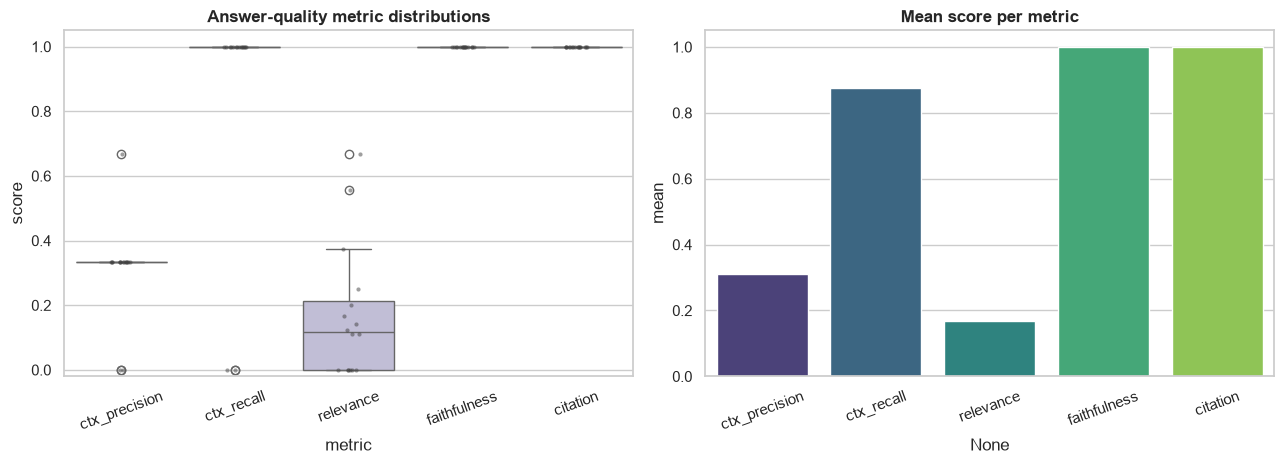

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
melted = frame[metric_cols].melt(var_name="metric", value_name="score")
sns.boxplot(data=melted, x="metric", y="score", hue="metric", palette="Set3", legend=False, ax=axes[0])
sns.stripplot(data=melted, x="metric", y="score", color="0.25", size=3, alpha=0.5, ax=axes[0])
axes[0].set_title("Answer-quality metric distributions", weight="bold")
axes[0].set_ylim(-0.02, 1.05)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(x=summary.index, y=summary["mean"], hue=summary.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Mean score per metric", weight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("mean")
plt.tight_layout()
plt.show()

## 3. Operational budgets: latency and tokens

Quality is necessary but not sufficient — a faithful answer that blows the
latency or cost budget still fails in production. We track both as
**distributions**, because tail behaviour, not the average, is what breaks under
load.

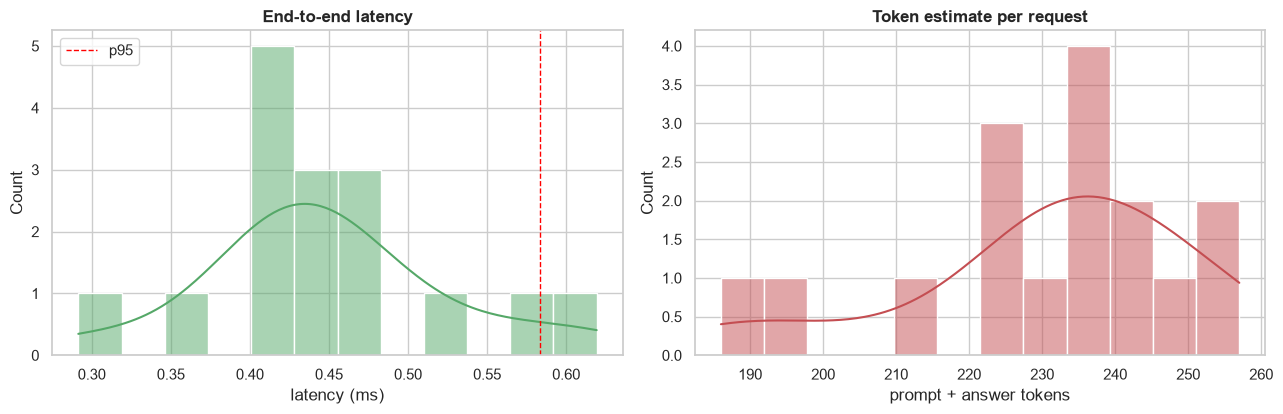

,budget
latency p50 (ms),0.439
latency p95 (ms),0.584
tokens p50,235.000
tokens p95,253.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
sns.histplot(frame.latency_ms, bins=12, kde=True, color="#55A868", ax=axes[0])
axes[0].axvline(frame.latency_ms.quantile(0.95), color="red", ls="--", lw=1, label="p95")
axes[0].set_title("End-to-end latency", weight="bold")
axes[0].set_xlabel("latency (ms)")
axes[0].legend()
sns.histplot(frame.tokens, bins=12, kde=True, color="#C44E52", ax=axes[1])
axes[1].set_title("Token estimate per request", weight="bold")
axes[1].set_xlabel("prompt + answer tokens")
plt.tight_layout()
plt.show()

pd.Series(
    {
        "latency p50 (ms)": round(frame.latency_ms.quantile(0.50), 3),
        "latency p95 (ms)": round(frame.latency_ms.quantile(0.95), 3),
        "tokens p50": int(frame.tokens.quantile(0.50)),
        "tokens p95": int(frame.tokens.quantile(0.95)),
    }
).to_frame("budget")

## 4. The regression gate

This is the heart of evaluation-first development: aggregate metrics are checked
against explicit thresholds, and the run **fails** if any check is breached —
exactly what a CI job does to block a regression from merging. The thresholds
below are strict on grounding (faithfulness, citation support) and looser on
retrieval recall. The diagnostic metrics from section 2 (`ctx_precision`,
`relevance`) are intentionally *not* gated — gating a weak lexical proxy would
produce noise, not safety.

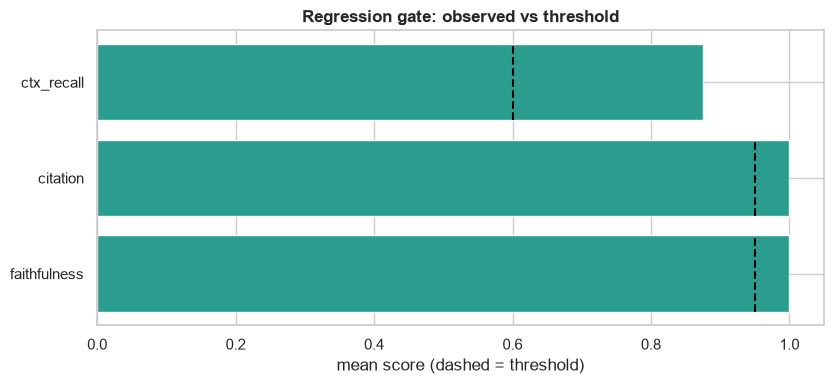

,metric,observed,threshold,pass
0,faithfulness,1.000,0.95,True
1,citation,1.000,0.95,True
2,ctx_recall,0.875,0.60,True


In [7]:
THRESHOLDS = {
    "faithfulness": 0.95,
    "citation": 0.95,
    "ctx_recall": 0.60,
}

gate = []
for metric, floor in THRESHOLDS.items():
    observed = float(frame[metric].mean())
    gate.append(
        {"metric": metric, "observed": round(observed, 3), "threshold": floor, "pass": observed >= floor}
    )
gate_df = pd.DataFrame(gate)

fig, ax = plt.subplots(figsize=(8.5, 4))
colors = gate_df["pass"].map({True: "#2A9D8F", False: "#E76F51"})
ax.barh(gate_df["metric"], gate_df["observed"], color=colors)
for y, (_, row) in enumerate(gate_df.iterrows()):
    ax.plot([row["threshold"], row["threshold"]], [y - 0.4, y + 0.4], color="black", ls="--", lw=1.5)
ax.set_title("Regression gate: observed vs threshold", weight="bold")
ax.set_xlim(0, 1.05)
ax.set_xlabel("mean score (dashed = threshold)")
plt.tight_layout()
plt.show()
gate_df

In [8]:
passed = bool(gate_df["pass"].all())
print("GATE:", "PASS ✅ — safe to merge" if passed else "FAIL ❌ — blocking regression")
print("(in CI this maps to exit code 0 / 1)")
assert passed, "Evaluation gate failed"

GATE: PASS ✅ — safe to merge
(in CI this maps to exit code 0 / 1)


## 5. Export artifacts

A CI job uploads its evaluation outputs for inspection. We export an aggregate
JSON, a per-question CSV, and a Markdown report for the worst-scoring question
into `artifacts/evaluation/`.

In [9]:
EVAL_DIR.mkdir(parents=True, exist_ok=True)

aggregate = {
    "questions": int(len(frame)),
    "means": {m: round(float(frame[m].mean()), 4) for m in metric_cols},
    "latency_ms_p95": round(float(frame.latency_ms.quantile(0.95)), 4),
    "gate_passed": passed,
    "thresholds": THRESHOLDS,
}
(EVAL_DIR / "aggregate.json").write_text(json.dumps(aggregate, indent=2), encoding="utf-8")
frame.round(4).to_csv(EVAL_DIR / "per_question.csv", index=False)

# "worst" by the weakest diagnostic (relevance), since grounding is uniformly high
worst_q = frame.sort_values("relevance").iloc[0]["question"]
worst_question = next(q for q in results_by_q if q.startswith(worst_q))
_, worst_ctx, worst_eval = results_by_q[worst_question]
export_evaluation_report_csv(worst_eval, EVAL_DIR / "worst_case.csv")
export_evaluation_report_markdown(worst_eval, EVAL_DIR / "worst_case.md")

print("wrote:", sorted(p.name for p in EVAL_DIR.glob("*")))
print()
print((EVAL_DIR / "worst_case.md").read_text())

wrote: ['aggregate.json', 'per_question.csv', 'report.csv', 'report.md', 'worst_case.csv', 'worst_case.md']

# Evaluation Report

- Context precision: 0.33
- Context recall: 1.00
- Answer relevance: 0.00
- Faithfulness: 1.00
- Citation support: 1.00
- Unsupported claims: 0
- Refusal correct: None


## Takeaways

- The full pipeline is **measured and gated**, not just demonstrated: every
  answer is tied to retrieved evidence, scored, traced, and checked against
  thresholds that would block a CI merge.
- Quality and operational budgets are tracked together — faithfulness *and* p95
  latency — because production cares about both.
- Every artifact here (`aggregate.json`, `per_question.csv`, traces, the worst-
  case report) is the kind of output a regression job uploads for review.

Swapping the heuristic client and fake embedder for hosted models changes only
their construction — this evaluation harness, and the gate, stay exactly the
same. That is the point of building evaluation-first.